In [1]:
import pandas as pd 

df = pd.read_csv("../dataset/supply_chain_data_cleaned.csv")


In [2]:
df.head()

,order_id,product,city,supplier,price,quantity,order_date,delivery_date,warehouse,transport_cost,discount,customer_rating,returned,payment_method,delivery_status,notes
0,ORD1000,Monitor,Bangalore,Supplier B,5132.0,11,2023-12-25,2023-05-05,WH2,300.0,0.0,NaN,No,Upi,Delivered,No Notes
1,ORD1001,Keyboard,Hyderabad,Supplier B,32683.0,2,2023-06-10,2023-12-22,Unknown,200.0,10.0,NaN,Yes,Upi,Cancelled,late delivery
2,ORD1002,Tablet,Hyderabad,Supplier B,1844.0,1,2023-03-06,2023-06-27,WH1,100.0,10.0,1.0,Yes,Unknown,Pending,urgent
3,ORD1003,Keyboard,Chennai,Supplier C,32869.0,10,2023-11-05,2023-09-10,WH3,100.0,0.0,NaN,Yes,Card,Pending,No Notes
4,ORD1004,Keyboard,Mumbai,Unknown,32516.0,12,2023-08-03,2023-09-19,Unknown,200.0,0.0,3.0,No,Card,Delivered,No Notes


In [3]:
df.describe()

,price,quantity,transport_cost,discount,customer_rating
count,12000.000000,12000.000000,12000.000000,12000.000000,9937.000000
mean,25297.627417,9.941333,243.975000,6.636250,2.985408
std,14071.127311,5.481626,76.174249,5.531936,1.425727
min,1001.000000,1.000000,100.000000,0.000000,1.000000
25%,13170.000000,5.000000,200.000000,0.000000,2.000000
50%,25250.000000,10.000000,300.000000,5.000000,3.000000
75%,37441.500000,15.000000,300.000000,10.000000,4.000000
max,49995.000000,19.000000,300.000000,15.000000,5.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         12000 non-null  str    
 1   product          12000 non-null  str    
 2   city             12000 non-null  str    
 3   supplier         12000 non-null  str    
 4   price            12000 non-null  float64
 5   quantity         12000 non-null  int64  
 6   order_date       12000 non-null  str    
 7   delivery_date    12000 non-null  str    
 8   warehouse        12000 non-null  str    
 9   transport_cost   12000 non-null  float64
 10  discount         12000 non-null  float64
 11  customer_rating  9937 non-null   float64
 12  returned         12000 non-null  str    
 13  payment_method   12000 non-null  str    
 14  delivery_status  12000 non-null  str    
 15  notes            12000 non-null  str    
dtypes: float64(4), int64(1), str(11)
memory usage: 1.5 MB


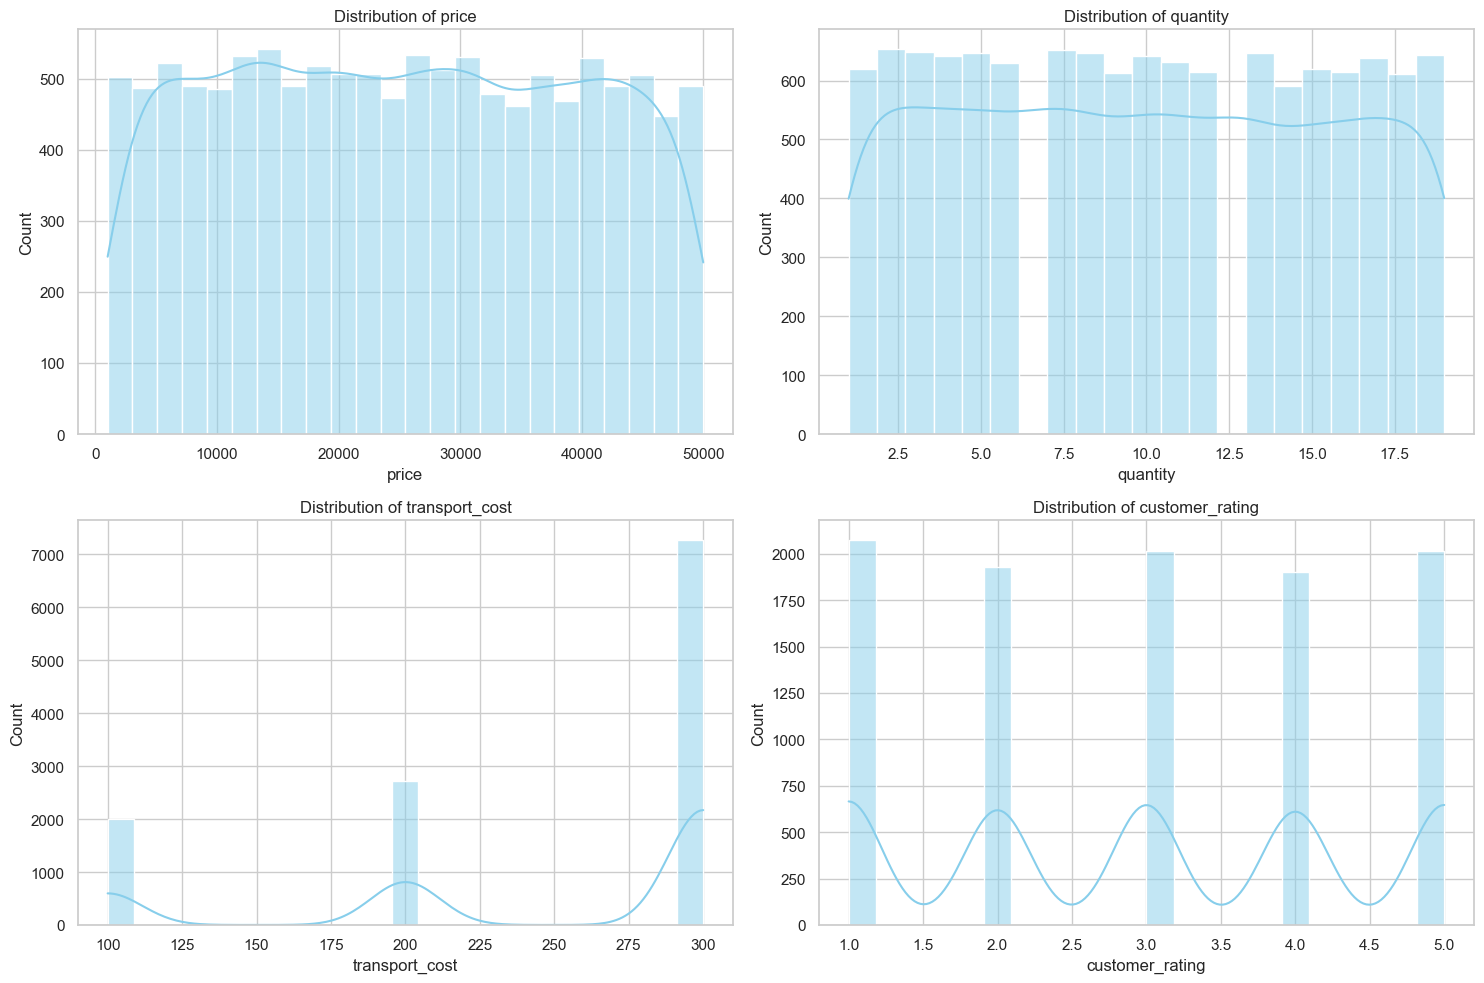

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting the visual style
sns.set_theme(style="whitegrid")

# Selecting numerical columns
num_cols = ['price', 'quantity', 'transport_cost', 'customer_rating']

# Plotting distributions
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Which City or Product appears to be the leader in your charts?

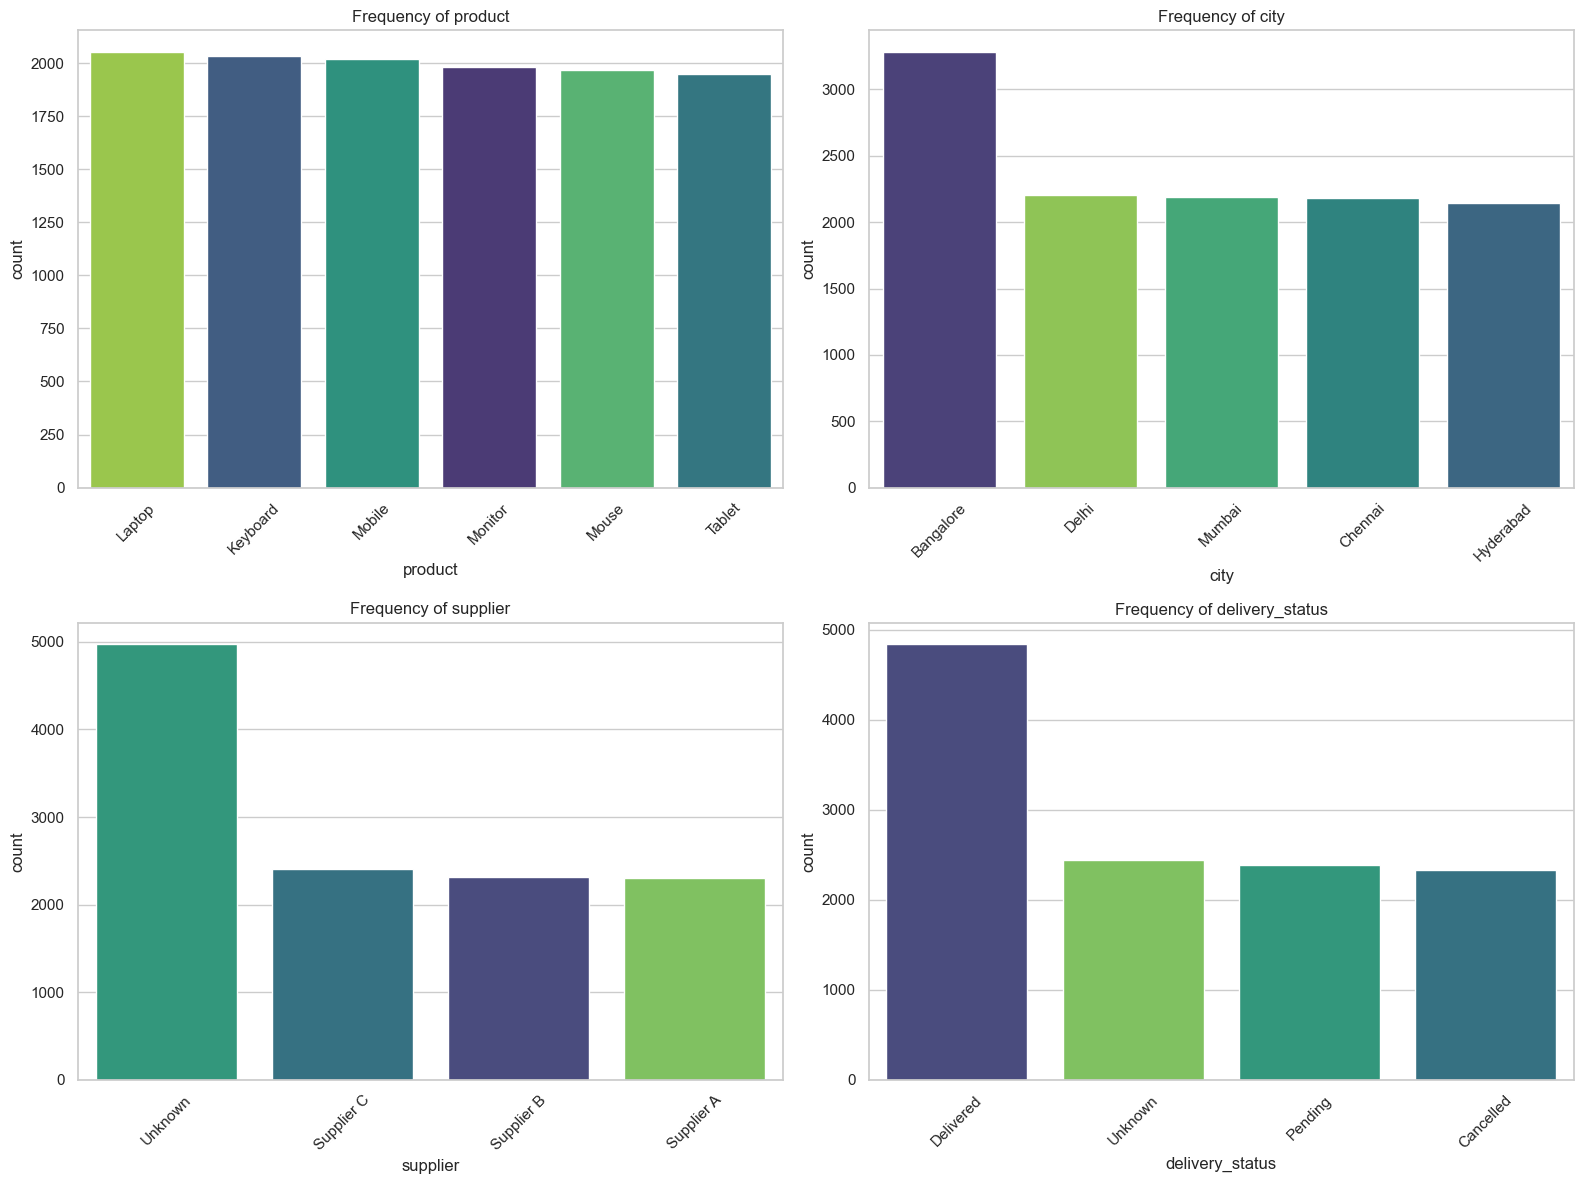

In [13]:
# Updated loop to fix the FutureWarning
plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    # Mapping x to hue and setting legend=False as suggested by the warning
    sns.countplot(data=df, x=col, hue=col, palette='viridis', 
                  order=df[col].value_counts().index, legend=False)
    plt.title(f'Frequency of {col}')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [14]:
#Bivariate Analysis (The "City" Deep Dive)

#City vs. Product: Which products are driving the volume in Bangalore?

#City vs. Delivery Status: Is Bangalore more "efficient" (more Delivered) or "problematic" (more Cancelled)?

#City vs. Transport Cost: Are we paying more to ship to Bangalore?

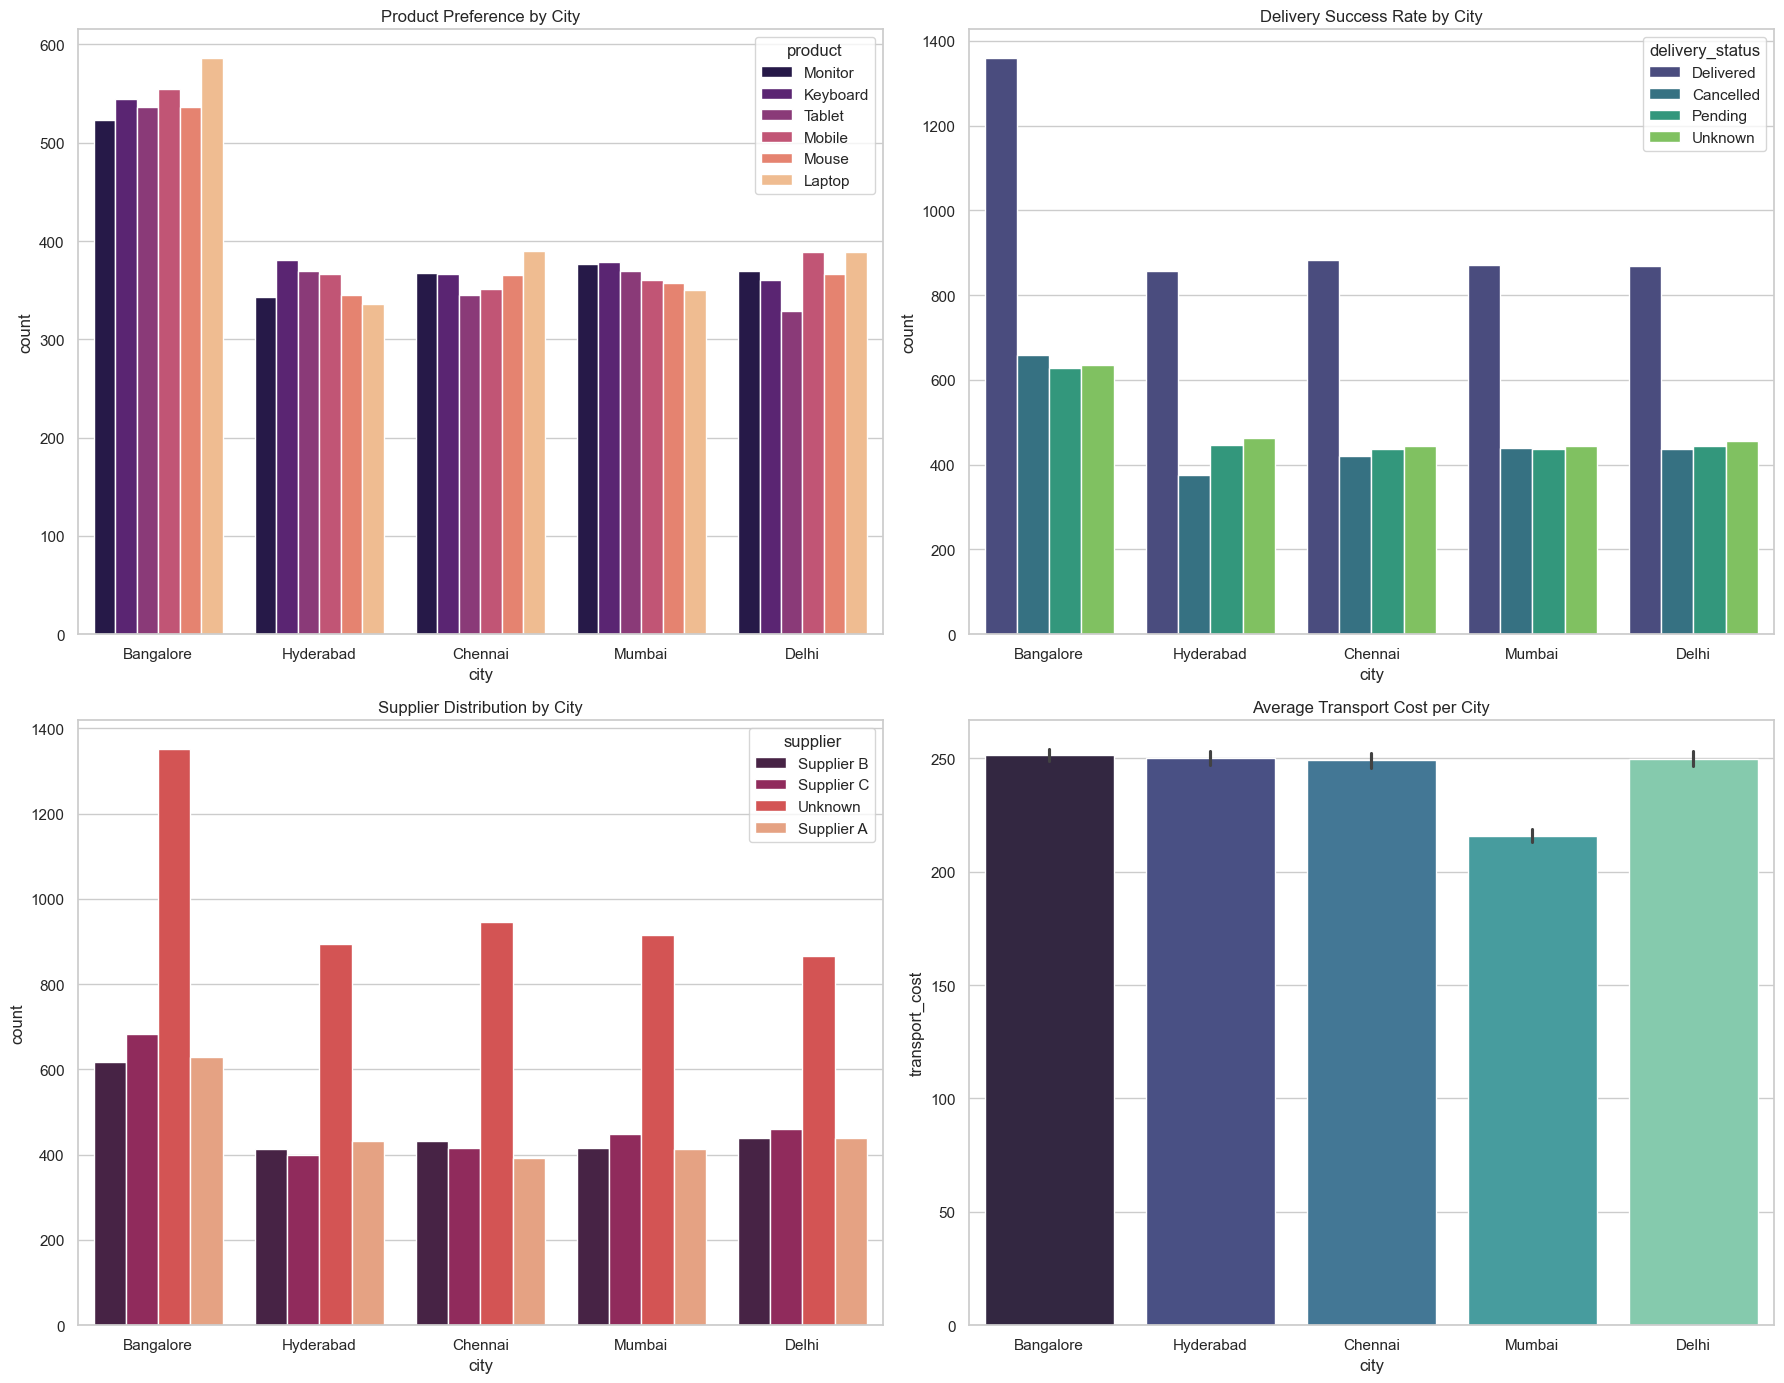

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# 1. City vs Product (Who buys what?)
sns.countplot(data=df, x='city', hue='product', ax=axes[0, 0], palette='magma')
axes[0, 0].set_title('Product Preference by City')

# 2. City vs Delivery Status (Efficiency check)
sns.countplot(data=df, x='city', hue='delivery_status', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('Delivery Success Rate by City')

# 3. City vs Supplier (Who is serving Bangalore?)
sns.countplot(data=df, x='city', hue='supplier', ax=axes[1, 0], palette='rocket')
axes[1, 0].set_title('Supplier Distribution by City')

# 4. City vs Transport Cost (Average cost per city)
sns.barplot(data=df, x='city', y='transport_cost', ax=axes[1, 1], palette='mako', hue='city', legend=False)
axes[1, 1].set_title('Average Transport Cost per City')

plt.tight_layout()
plt.show()

In [ ]:
# Since we found this mystery supplier is the backbone of Bangalore, let’s see if they 
# are actually doing a good job. We should check if "Unknown" is linked to high returns or bad ratings.

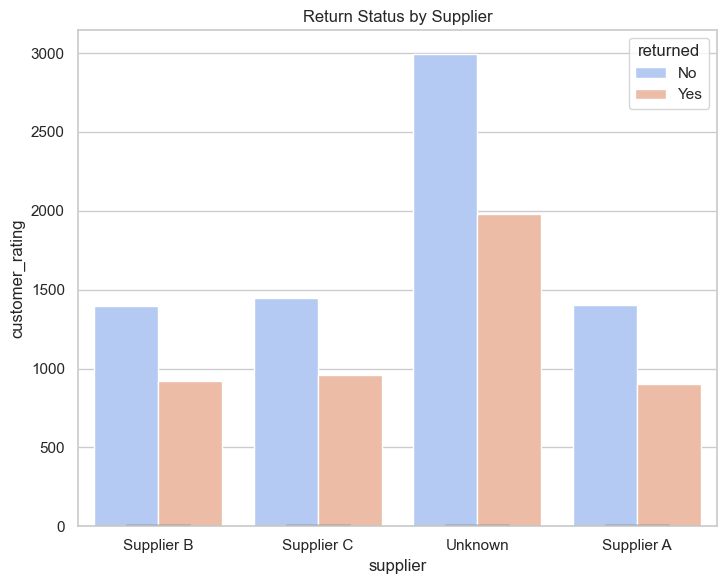

In [17]:
# Comparing Supplier Performance
plt.figure(figsize=(14, 6))

# 1. Supplier vs Customer Rating
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='supplier', y='customer_rating', palette='Set2', hue='supplier', legend=False)
plt.title('Rating Distribution by Supplier')

# 2. Supplier vs Returned (Is 'Unknown' causing more returns?)
sns.countplot(data=df, x='supplier', hue='returned', palette='coolwarm')
plt.title('Return Status by Supplier')

plt.tight_layout()
plt.show()

# Correlation Analysis (The Final Piece)

In [19]:
df['total_spend'] = df['price'] * df['quantity']

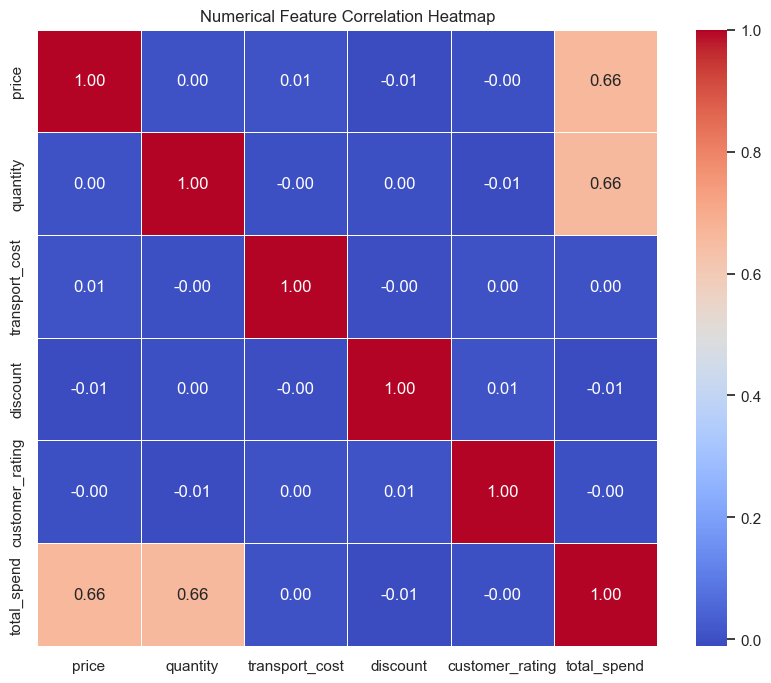

In [20]:
# Correlation Heatmap for Numerical Variables
plt.figure(figsize=(10, 8))

# We only correlate numerical columns
numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Numerical Feature Correlation Heatmap')
plt.show()

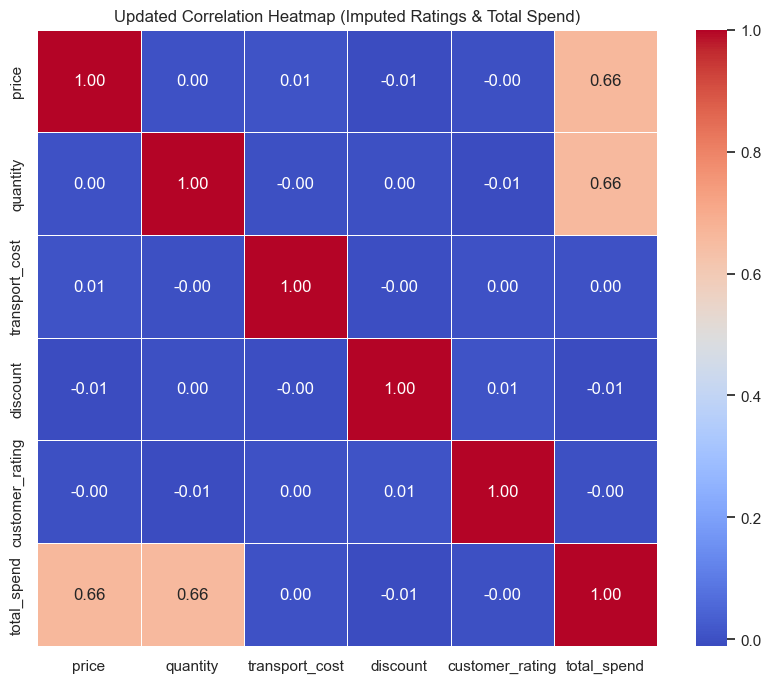

Missing ratings remaining: 0


In [21]:
# 1. Fill NaN values in customer_rating with the median
median_rating = df['customer_rating'].median()
df['customer_rating'] = df['customer_rating'].fillna(median_rating)

# 2. Re-run the correlation with the new 'total_spend' column
# This will show a much stronger relationship in your heatmap!
numerical_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Updated Correlation Heatmap (Imputed Ratings & Total Spend)')
plt.show()

# 3. Quick check to ensure no NaNs remain
print(f"Missing ratings remaining: {df['customer_rating'].isnull().sum()}")

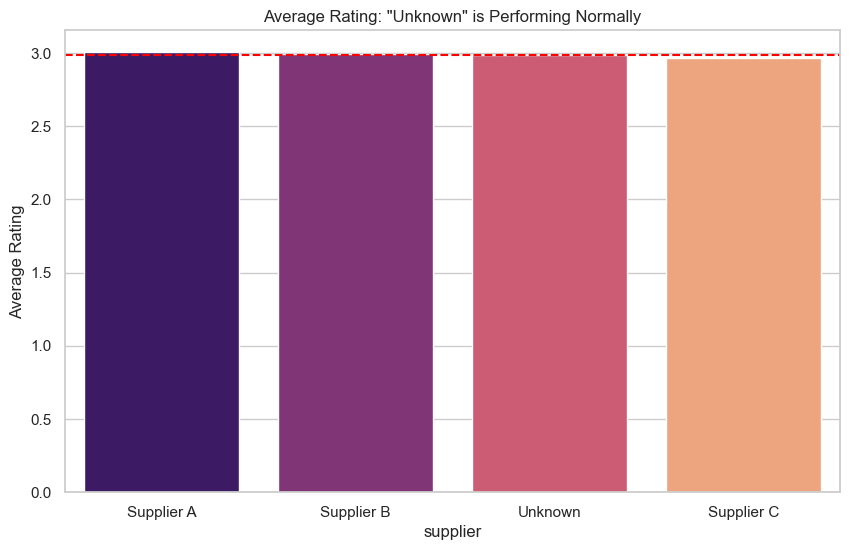

In [23]:
# Updated code to fix the FutureWarning
plt.figure(figsize=(10, 6))
sns.barplot(
    x=supplier_performance.index, 
    y=supplier_performance.values, 
    hue=supplier_performance.index, # Assign hue to the x variable
    palette='magma', 
    legend=False                   # Turn off the legend as requested
)
plt.axhline(df['customer_rating'].mean(), color='red', linestyle='--', label='Global Average')
plt.title('Average Rating: "Unknown" is Performing Normally')
plt.ylabel('Average Rating')
plt.show()

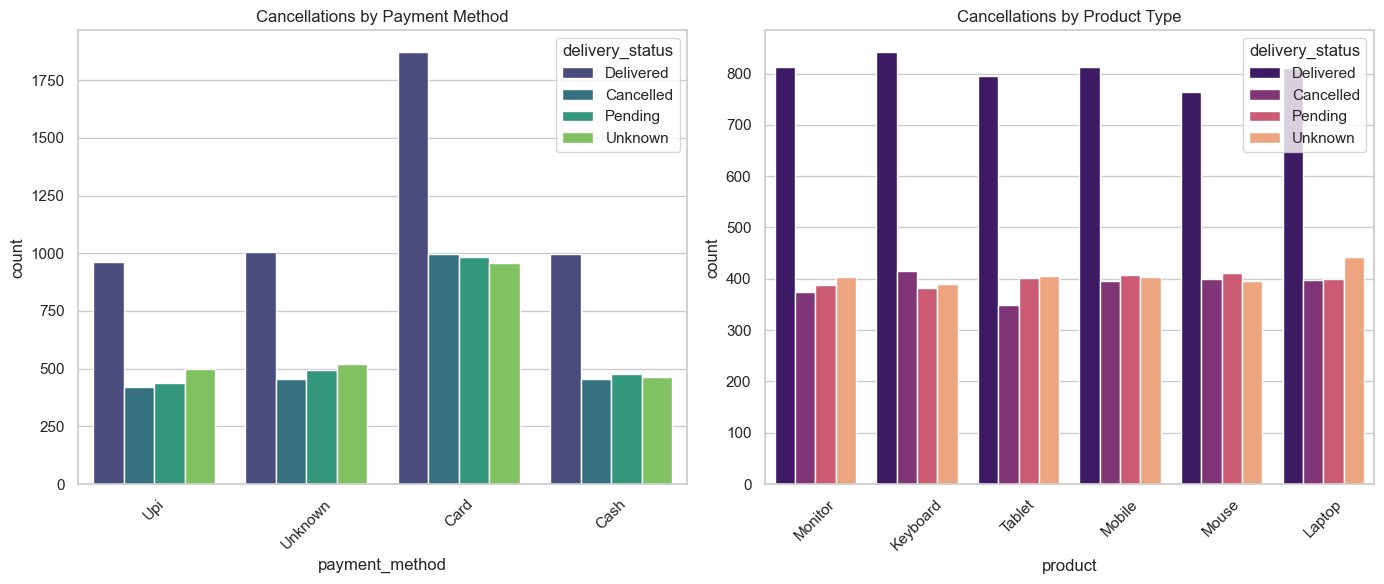

Cancellation Rate by Payment Method:
payment_method
Card       42.771343
Unknown    19.605320
Cash       19.562420
Upi        18.060918
Name: proportion, dtype: float64


In [24]:
# Check which Payment Methods or Products result in the most cancellations
plt.figure(figsize=(14, 6))

# 1. Payment Method vs Delivery Status
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='payment_method', hue='delivery_status', palette='viridis')
plt.title('Cancellations by Payment Method')
plt.xticks(rotation=45)

# 2. Product vs Delivery Status
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='product', hue='delivery_status', palette='magma')
plt.title('Cancellations by Product Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Proportional check: Are cancellations actually higher for specific methods?
print("Cancellation Rate by Payment Method:")
print(df[df['delivery_status'] == 'Cancelled']['payment_method'].value_counts(normalize=True) * 100)

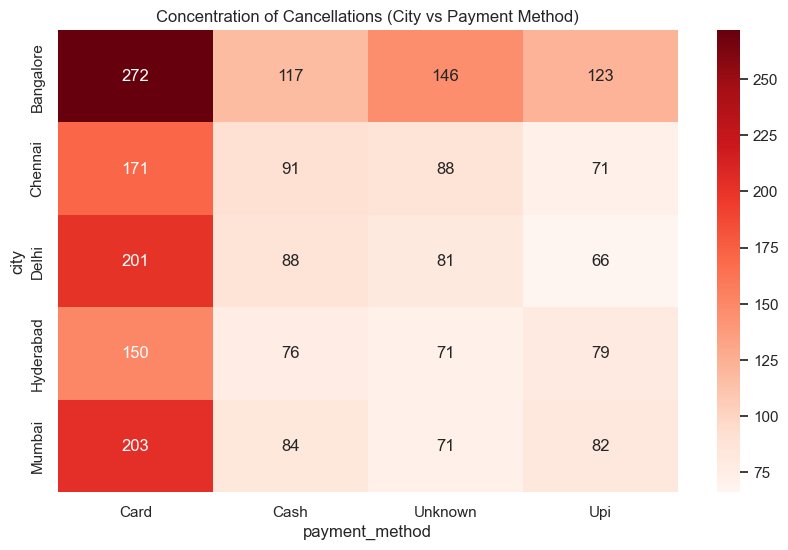

In [25]:
# Heatmap of Cancellations by City and Payment Method
cancellation_pivot = df[df['delivery_status'] == 'Cancelled'].pivot_table(
    index='city', 
    columns='payment_method', 
    values='order_id', 
    aggfunc='count'
)

plt.figure(figsize=(10, 6))
sns.heatmap(cancellation_pivot, annot=True, cmap='Reds', fmt='g')
plt.title('Concentration of Cancellations (City vs Payment Method)')
plt.show()

--- TOP PRIORITY: REVENUE AT RISK ---
City: Bangalore  | Revenue Lost via Card Cancellations: ₹6,895,498.00
City: Mumbai     | Revenue Lost via Card Cancellations: ₹5,664,201.00
City: Delhi      | Revenue Lost via Card Cancellations: ₹5,075,179.00


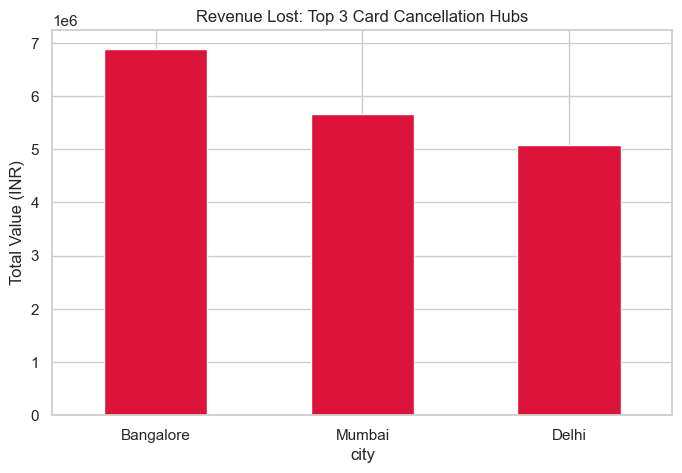

In [28]:
# Filtering for the high-priority failure zones
priority_zones = df[(df['delivery_status'] == 'Cancelled') & (df['payment_method'] == 'Card')]
priority_summary = priority_zones.groupby('city')['price'].sum().sort_values(ascending=False).head(3)


print("--- TOP PRIORITY: REVENUE AT RISK ---")
for city, loss in priority_summary.items():
    print(f"City: {city:10} | Revenue Lost via Card Cancellations: ₹{loss:,.2f}")

# Visualizing the scale of the problem
plt.figure(figsize=(8, 5))
priority_summary.plot(kind='bar', color='crimson')
plt.title('Revenue Lost: Top 3 Card Cancellation Hubs')
plt.ylabel('Total Value (INR)')
plt.xticks(rotation=0)
plt.show()

In [29]:
# Checking customer notes for these cancellations in the top cities 

--- Analysis of Notes for Bangalore Card Cancellations (Total: 272) ---
notes
check address    86
No Notes         67
late delivery    65
urgent           54
Name: count, dtype: int64


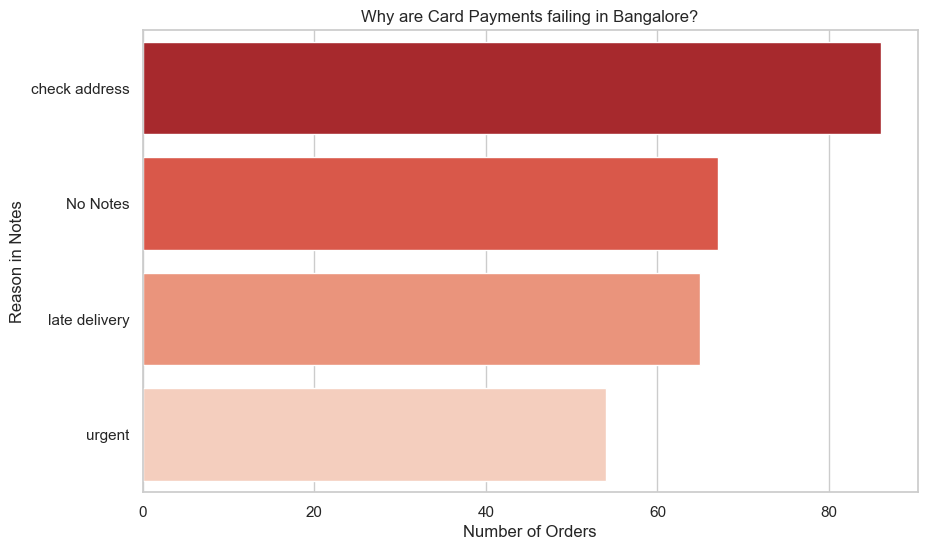

In [30]:
# 1. Isolate the specific high-priority segment: Bangalore + Card + Cancelled
bangalore_card_failures = df[
    (df['city'] == 'Bangalore') & 
    (df['payment_method'] == 'Card') & 
    (df['delivery_status'] == 'Cancelled')
]

# 2. Count the occurrences of each note in this segment
note_analysis = bangalore_card_failures['notes'].value_counts()

print(f"--- Analysis of Notes for Bangalore Card Cancellations (Total: {len(bangalore_card_failures)}) ---")
print(note_analysis)

# 3. Visualize the reasons
plt.figure(figsize=(10, 6))
sns.barplot(x=note_analysis.values, y=note_analysis.index, hue=note_analysis.index, palette='Reds_r', legend=False)
plt.title('Why are Card Payments failing in Bangalore?')
plt.xlabel('Number of Orders')
plt.ylabel('Reason in Notes')
plt.show()